# ANÁLISIS EXPLORATORIO Y TRANSFORMACIÓN DE DATOS

### Librerias y Carga de datos


Este documento presenta el **Análisis Exploratorio de Datos (EDA)** y la etapa de **Limpieza y Transformación** del corpus clínico. El propósito fundamental es preparar datos radiológicos crudos para fases posteriores de entrenamiento en modelos predictivos. Esto abarca desde la depuración de valores anómalos hasta la normalización del texto de los reportes médicos, finalizando con una estrategia basada en diccionarios para la anotación estructurada de patologías craneales.

In [1]:
!pip install pandas numpy matplotlib seaborn plotly
!pip install scikit-learn scipy
!pip install missingno
!pip install sweetviz
!pip install pandas-profiling
!pip install imbalanced-learn
!pip install openpyxl
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


...

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.2.0 requires joblib~=1.1.0, but you have joblib 1.5.3 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Importación de librerías para EDA y preprocesamiento de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re
import unicodedata
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy import stats

# Configuración de visualización
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Configuración de warnings
import warnings
warnings.filterwarnings('ignore')

### 1. Ingesta y Exploración Inicial del Conjunto de Datos
La base de datos original contiene registros correspondientes a estudios diagnósticos. En primer lugar, se filtra la información priorizando aquellos exámenes catalogados bajo un criterio de `Hallazgo Crítico`, y se examina la presencia de posibles inconsistencias o valores nulos inherentes a la historia clínica automatizada.

In [3]:
df = pd.read_excel('../data/data.xlsx')

print(f"Datos originales:")
print(f"  - Filas: {df.shape[0]}")
print(f"  - Columnas: {df.shape[1]}")

# Filtrar solo casos críticos
# df = df[df['Hallazgo Crítico'] == 1]

print(f"\n{'='*50}")
print(f"Después de filtrar por casos críticos:")
print(f"  - Filas: {df.shape[0]}")
print(f"  - Columnas: {df.shape[1]}")

print(f"\nValores nulos después del filtrado:")
print(df.isnull().sum())


Datos originales:
  - Filas: 3984
  - Columnas: 11

Después de filtrar por casos críticos:
  - Filas: 3984
  - Columnas: 11

Valores nulos después del filtrado:
Fecha(dd/mm/yyyy)                  0
Modalidad                          0
Estudio                            0
Técnica                            3
Datos Clínicos                     6
Hallazgos                          4
Opinión                            4
Reporte estructurado               0
Estudio Complementario Sugerido    0
Hallazgo Crítico                   0
Estudio Normal                     1
dtype: int64


In [4]:
df_sample = df.sample(100, random_state=42)

In [19]:
# Revisar registros con valores nulos en columnas clave antes de limpiar
print("\nRegistros con Datos Clínicos nulo:")
display(df[df['Datos Clínicos'].isnull()])
print("\nRegistro con Hallazgos nulo:")
display(df[df['Hallazgos'].isnull()])
print("\nRegistros con Opinión nulo:")
display(df[df['Opinión'].isnull()])


Registros con Datos Clínicos nulo:


,Fecha(dd/mm/yyyy),Modalidad,Estudio,Técnica,Datos Clínicos,Hallazgos,Opinión,Reporte estructurado,Estudio Complementario Sugerido,Hallazgo Crítico,Estudio Normal
550,2019-02-15 00:00:00,CT,TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE,Se realizan cortes axiales desde fosa posterio...,NaN,"Parénquima cerebral de densidad homogénea, s...",TOMOGRAFIA AXIAL COMPUTARIZADA CEREBRAL SIMPL...,0,0,0,1.0
767,2019-03-05 00:00:00,CT,TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE,"En equipo multidetector, se realizan cortes ax...",NaN,La atenuación del parénquima es normal y no se...,Estudio sin evidencia de lesión traumática int...,0,0,0,1.0
3107,2019-08-26 00:00:00,CT,TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE,En equipo multidetector se adquieren imágenes ...,NaN,SIGNOS DE SANGRADO.\nHEMATOMA SUBDURAL: No.\nH...,Estudio sin evidencia de proceso intracraneal ...,0,0,0,0.0
3704,2025-01-07 20:06:25,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,"961.5 DLP (mGy - cm)\nEn equipo multidetector,...",NaN,Cambios postquirúrgicos por orificios de trépa...,Hematoma subdural fronto-temporoparietal izqui...,0,0,1,0.0
3828,2025-06-09 00:00:00,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,1279.55 DLP (mGy - cm)\nMedio de contraste: NO...,NaN,En este control se observa nueva pérdida difus...,Pérdida difusa de la diferenciación entre sust...,0,0,1,0.0
3961,2025-05-03 00:00:00,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,882.7 DLP (mGy - cm)\nMedio de contraste: NO A...,NaN,NaN,NaN,0,0,1,0.0



Registro con Hallazgos nulo:


,Fecha(dd/mm/yyyy),Modalidad,Estudio,Técnica,Datos Clínicos,Hallazgos,Opinión,Reporte estructurado,Estudio Complementario Sugerido,Hallazgo Crítico,Estudio Normal
84,2019-01-08 00:00:00,CT,TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE,Se realizan cortes axiales desde fosa posterio...,Imágenes hipodensas mal definidas de la sustan...,NaN,Signos de leucoencefalopatía microangiopática....,0,0,0,0.0
286,2019-01-25 00:00:00,CT,TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE,Se realizan cortes axiales desde fosa posterio...,Aneurisma sacular gigante del segmento oftálmi...,NaN,Comparativamente con el estudio previo se obse...,0,0,0,0.0
1275,2019-04-11 00:00:00,CT,TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE,"En equipo multidetector, se realizan cortes ax...",PACIENTE CON SOSPECHA DE ACV HEMORRAGICO REQUI...,NaN,Estudio sin cambios significativos respecto es...,0,0,0,0.0
3961,2025-05-03 00:00:00,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,882.7 DLP (mGy - cm)\nMedio de contraste: NO A...,NaN,NaN,NaN,0,0,1,0.0



Registros con Opinión nulo:


,Fecha(dd/mm/yyyy),Modalidad,Estudio,Técnica,Datos Clínicos,Hallazgos,Opinión,Reporte estructurado,Estudio Complementario Sugerido,Hallazgo Crítico,Estudio Normal
192,2019-01-17 00:00:00,CT,TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE,Se realizan cortes axiales desde fosa posterio...,Cefalea intensa frontal y retroocular derecha,Surcos y circunvoluciones simétricos.\n\nSiste...,NaN,0,0,0,1.0
457,2019-02-08 00:00:00,CT,TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE,Se realizan cortes axiales desde fosa posterio...,"Enfermedad de Parkinson, ahora delírium hipoac...",SIGNOS DE SANGRADO.\n\nHEMATOMA SUBDURAL: No.\...,NaN,1,0,0,0.0
3805,2025-06-15 00:00:00,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,2674.8 DLP (mGy - cm)\nMedio de contraste: NO ...,POLITRAUMA POR ACCIDENTE DE TRANSITO -.,Hematoma epidural frontal izquierdo con espeso...,NaN,0,0,1,0.0
3961,2025-05-03 00:00:00,CT,TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE,882.7 DLP (mGy - cm)\nMedio de contraste: NO A...,NaN,NaN,NaN,0,0,1,0.0


In [20]:
# Rellenar valores nulos en columnas secundarias
df['Datos Clínicos'] = df['Datos Clínicos'].fillna('NR')
df['Técnica'] = df['Técnica'].fillna('NR')
df['Estudio Normal'] = df['Estudio Normal'].fillna(0)

# Eliminamos las filas con nulos en columnas críticas ('Hallazgos' u 'Opinión')
registros_antes = df.shape[0]
df = df.dropna(subset=['Hallazgos', 'Opinión'])
registros_despues = df.shape[0]

# Imprimir el resumen del filtrado
print("=== RESUMEN DE LIMPIEZA DE DATOS ===")
print(f"Registros antes de limpieza: {registros_antes}")
print(f"Registros eliminados: {registros_antes - registros_despues}")
print(f"Total de registros finales para análisis: {registros_despues}")
print("====================================")

# Verificar valores nulos después de la limpieza
print("\nVerificación de nulos restantes:")
print(df.isnull().sum())

=== RESUMEN DE LIMPIEZA DE DATOS ===
Registros antes de limpieza: 3984
Registros eliminados: 7
Total de registros finales para análisis: 3977

Verificación de nulos restantes:
Fecha(dd/mm/yyyy)                  0
Modalidad                          0
Estudio                            0
Técnica                            0
Datos Clínicos                     0
Hallazgos                          0
Opinión                            0
Reporte estructurado               0
Estudio Complementario Sugerido    0
Hallazgo Crítico                   0
Estudio Normal                     0
dtype: int64


### 2. Normalización de Texto (Procesamiento de Lenguaje Natural)
Gran parte del valor diagnóstico recae en atributos de texto libre. A modo de buena práctica para posteriores representaciones vectoriales, se aplican funciones de estandarización sintáctica: conversión a minúsculas, remoción de espacios sobrantes y homogeneización de signos de puntuación, mitigando el ruido estadístico.

In [21]:
# Columnas de texto no estructurado a normalizar
text_columns = ['Técnica', 'Datos Clínicos', 'Hallazgos', 'Opinión']

for col in text_columns:
    # Convertir a string (por si hay valores numéricos o NaN)
    df[col] = df[col].astype(str)
    
    # Convertir a minúsculas
    df[col] = df[col].str.lower()
    
    # Eliminar espacios extra al inicio y final
    df[col] = df[col].str.strip()
    
    # Reemplazar múltiples espacios por un solo espacio
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)
    
    # Normalizar puntuación: agregar espacio después de puntos, comas, etc.
    df[col] = df[col].str.replace(r'([.,:;!?])', r'\1 ', regex=True)
    
    # Eliminar espacios extra nuevamente
    df[col] = df[col].str.replace(r'\s+', ' ', regex=True)

print("Normalización de texto no estructurado completada")

Normalización de texto no estructurado completada


### 2b. Pipeline de Limpieza de Texto Médico Robusta

La limpieza anterior (Cell 10) cubre normalización básica de caracteres. Esta etapa agrega un **filtrado semántico en capas** que elimina el ruido lingüístico de los reportes radiológicos, conservando **solo terminología médica técnica**:

| Capa | Qué elimina | Ejemplos |
|------|-------------|----------|
| 1 | Stopwords estándar del español | *de, la, y, el, en, hay* |
| 2 | Frases multi-palabra de reporte | *hay evidencia, se observa, se evidencia, porciones visualizadas* |
| 3 | Verbos de reporte radiológico | *observan, evidencia, identifica, muestra, sugiere* |
| 4 | Términos temporales/seguimiento | *estudio previo, anterior, previo, previos* |
| 5 | Tokens muy cortos (< 3 chars) | *ni, al, lo* |
| ✓ | **Whitelist médica protegida** | *hemorragia, isquemia, fractura, masa, agudo, cisura…* |

Las columnas originales se **preservan intactas**; el texto limpio se escribe en `Hallazgos_limpio` y `Opinión_limpio`.

In [22]:
import re
import unicodedata
from typing import List, Optional

# ═══════════════════════════════════════════════════════════════
# CAPA 1: STOPWORDS GENERALES DEL ESPAÑOL
# ═══════════════════════════════════════════════════════════════
STOPWORDS_ES = {
    # Artículos
    'el', 'la', 'los', 'las', 'un', 'una', 'unos', 'unas',
    # Preposiciones
    'a', 'ante', 'bajo', 'con', 'contra', 'de', 'desde', 'durante',
    'en', 'entre', 'hacia', 'hasta', 'mediante', 'para', 'por', 'segun',
    'sin', 'sobre', 'tras', 'versus', 'via',
    # Conjunciones
    'e', 'ni', 'o', 'u', 'y', 'pero', 'sino', 'aunque', 'porque',
    'como', 'cuando', 'donde', 'que', 'si', 'ya', 'tanto',
    # Pronombres / determinantes
    'al', 'del', 'lo', 'le', 'les', 'me', 'mi', 'mis', 'nos', 'se',
    'su', 'sus', 'te', 'tu', 'tus', 'yo', 'ella', 'ellos', 'ellas',
    'este', 'esta', 'estos', 'estas', 'ese', 'esa', 'esos', 'esas',
    'aquel', 'aquella', 'aquellos', 'aquellas',
    # Verbos auxiliares / copulativos
    'es', 'son', 'era', 'fue', 'ser', 'estar', 'hay', 'ha', 'han',
    'he', 'haber', 'tiene', 'tienen', 'tenia', 'tendria',
    # Adverbios genéricos
    'no', 'mas', 'muy', 'bien', 'mal', 'solo', 'tambien',
    'ademas', 'aun', 'incluso', 'asi',
    # Cuantificadores genéricos
    'todo', 'toda', 'todos', 'todas', 'otro', 'otra', 'otros', 'otras',
    'mismo', 'misma', 'mismos', 'mismas', 'cada', 'cualquier',
    'algunos', 'algunas', 'algun', 'ningun',
    # Números escritos
    'uno', 'dos', 'tres', 'cuatro', 'cinco', 'primer', 'segundo',
}

# ═══════════════════════════════════════════════════════════════
# CAPA 2: FRASES MULTI-PALABRA DE LENGUAJE NATURAL
# (se eliminan como unidad antes de tokenizar)
# ═══════════════════════════════════════════════════════════════
FRASES_RUIDO = [
    # Verbos de reporte
    r'\bhay evidencia\b', r'\bse evidencia\b', r'\bse evidencian\b',
    r'\bse observa\b', r'\bse observan\b',
    r'\bse identifica\b', r'\bse identifican\b',
    r'\bse aprecia\b', r'\bse aprecian\b',
    r'\bse visualiza\b', r'\bse visualizan\b',
    r'\bse demuestra\b', r'\bse demuestran\b',
    r'\bse nota\b', r'\bse notan\b',
    r'\bse detecta\b', r'\bse detectan\b',
    r'\bse documenta\b', r'\bse documentan\b',
    r'\bse describe\b', r'\bse describen\b',
    # Calificadores diagnósticos
    r'\bcompatible con\b', r'\bcompatibles con\b',
    r'\bsugestivo de\b', r'\bsugestiva de\b',
    r'\bsugestivos de\b', r'\bsugestivas de\b',
    r'\bsugerente de\b',
    r'\ben relacion con\b', r'\ben relacion a\b',
    r'\bcorresponde a\b', r'\bcorresponden a\b',
    r'\bpuede corresponder\b', r'\bpodria corresponder\b',
    r'\bpodria tratarse\b', r'\bpuede tratarse\b',
    r'\ba descartar\b', r'\bpor descartar\b',
    r'\ba considerar\b',
    # Frases de referencia a imagen previa / comparación
    r'\bestudio previo\b', r'\bestudios previos\b',
    r'\bimagen previa\b', r'\bimagenes previas\b',
    r'\bestudio anterior\b', r'\bestudios anteriores\b',
    r'\bcomparado con\b', r'\bcomparando con\b',
    r'\ben comparacion\b', r'\bcon respecto\b',
    r'\brespecto al estudio\b',
    # Frases de normalidad / ausencia de hallazgos
    r'\bporciones visualizadas\b', r'\bporcion visible\b',
    r'\bporciones visibles\b', r'\bporciones evaluadas\b',
    r'\bdentro de limites\b', r'\bdentro de los limites\b',
    r'\blimites normales\b',
    r'\bsin alteraciones\b', r'\bsin hallazgos\b',
    r'\bsin cambios\b', r'\bsin evidencia\b', r'\bsin signos\b',
    # Frases de contexto / recomendación
    r'\bse recomienda\b', r'\bse sugiere\b',
    r'\bse correlacione\b', r'\bse correlaciona\b',
    r'\ben el contexto\b', r'\ben contexto de\b',
    r'\bpor lo anterior\b', r'\bpor lo tanto\b', r'\bpor lo cual\b',
    r'\bde acuerdo con\b', r'\bde acuerdo a\b',
    r'\ba nivel de\b', r'\ba nivel del\b', r'\ba nivel\b',
    # Secciones del reporte
    r'\bimpresion diagnostica\b', r'\bimpresión diagnóstica\b',
    r'\bhallazgos:\b', r'\bopinion:\b', r'\btecnica:\b',
]

# ═══════════════════════════════════════════════════════════════
# CAPA 3: VERBOS DE REPORTE (unigramas)
# ═══════════════════════════════════════════════════════════════
VERBOS_REPORTE = {
    'observa', 'observan', 'observo', 'observaron',
    'evidencia', 'evidencian', 'evidencio', 'evidenciaron',
    'identifica', 'identifican', 'identifico', 'identificaron',
    'aprecia', 'aprecian', 'aprecio', 'apreciaron',
    'visualiza', 'visualizan', 'visualizo', 'visualizaron',
    'demuestra', 'demuestran', 'demostro', 'demostraron',
    'nota', 'notan', 'noto', 'notaron',
    'detecta', 'detectan', 'detecto', 'detectaron',
    'documenta', 'documentan', 'documento', 'documentaron',
    'describe', 'describen', 'describio', 'describieron',
    'reporta', 'reportan', 'reporto', 'reportaron',
    'muestra', 'muestran', 'mostro', 'mostraron',
    'presenta', 'presentan', 'presento', 'presentaron',
    'exhibe', 'exhiben', 'exhibio', 'exhibieron',
    'denota', 'denotan', 'denoto', 'denotaron',
    'sugiere', 'sugieren', 'sugirio', 'sugirieron',
    'corresponde', 'corresponden', 'correspondio',
    'recomienda', 'recomiendan',
    'correlacione', 'correlaciona', 'correlacionan',
    'concluye', 'concluyen', 'concluyo',
    'impresiona', 'impresionan',
}

# ═══════════════════════════════════════════════════════════════
# CAPA 4: TÉRMINOS TEMPORALES / SEGUIMIENTO
# ═══════════════════════════════════════════════════════════════
TEMPORALES_SEGUIMIENTO = {
    'previo', 'previa', 'previos', 'previas',
    'anterior', 'anteriores',
    'posterior', 'posteriores',
    'siguiente', 'siguientes',
    'reciente', 'recientes',
    'actual', 'actuales',
    'nuevo', 'nueva', 'nuevos', 'nuevas',
    'antiguo', 'antigua', 'antiguos', 'antiguas',
    'cronico', 'cronica', 'cronicos', 'cronicas',
    'viejo', 'vieja', 'viejos', 'viejas',
    'residual', 'residuales',
    'secuela', 'secuelas', 'secuelar',
    'estable', 'estables',
    'conocido', 'conocida', 'conocidos', 'conocidas',
}

# ═══════════════════════════════════════════════════════════════
# WHITELIST: términos médicos que NUNCA se eliminan
# ═══════════════════════════════════════════════════════════════
WHITELIST_MEDICA = {
    'hemorragia', 'hematoma', 'sangrado', 'sangre',
    'isquemia', 'isquemico', 'isquemica', 'infarto', 'ictus', 'acv',
    'fractura', 'fracturas', 'trazo', 'hundimiento',
    'masa', 'masas', 'tumor', 'tumoral', 'tumorales', 'neoplasia',
    'edema', 'aneurisma', 'hidrocefalia', 'hernia', 'herniacion',
    'contusion', 'contusiones', 'lesion', 'lesiones',
    'craneo', 'cerebro', 'cerebral', 'cerebrales',
    'corteza', 'cortical', 'subcortical',
    'lobulo', 'lobulos', 'parietal', 'frontal', 'temporal', 'occipital',
    'cerebelo', 'cerebeloso', 'cerebelosa',
    'tronco', 'troncoencefalico',
    'ventriculos', 'ventriculo', 'ventricular',
    'subaracnoideo', 'subaracnoidea', 'subdural', 'epidural',
    'intraparenquimatoso', 'intraparenquimatosa',
    'meningeo', 'meningeos', 'meninges',
    'hipocampo', 'hipocampal',
    'ganglios', 'basal', 'basales', 'talamo', 'talamica',
    'fosa', 'silla', 'turca', 'orbita', 'mastoides', 'petroso',
    'arteria', 'arterias', 'arterial', 'arteriales',
    'vena', 'venas', 'venoso', 'venosa',
    'carotida', 'carotidas', 'vertebral', 'vertebrales',
    'basilar', 'silviana',
    'hipodensidad', 'hipodensidades', 'hipodensa', 'hipodensas',
    'hiperdensidad', 'hiperdensidades', 'hiperdensa', 'hiperdensas',
    'isodensidad', 'isodensa',
    'densidad', 'densidades',
    'calcificacion', 'calcificaciones', 'calcificado', 'calcificada',
    'atrofia', 'atrofico', 'atrofica',
    'dilatacion', 'dilataciones', 'dilatado', 'dilatada',
    'desplazamiento', 'desviacion',
    'compresion', 'obliteracion', 'prominencia', 'prominente',
    'asimetria', 'asimetrico', 'asimetrica',
    'efecto',
    'hiperaguda', 'hiperagudo', 'subagudo', 'subaguda',
    'agudo',  # en radiología es diagnóstico (infarto agudo, etc.)
    'surcos', 'cisuras', 'cisura', 'surco',
    'parenquima', 'parenquimatoso', 'parenquimatosa',
    'diferenciacion', 'ipsilateral', 'contralateral',
    'bilateral', 'unilateral', 'difuso', 'difusa', 'focal', 'multifocal',
    'realce', 'contraste',
}

# ═══════════════════════════════════════════════════════════════
# FUNCIÓN PRINCIPAL
# ═══════════════════════════════════════════════════════════════
def limpiar_texto_medico(
    texto: str,
    stopwords_extra: Optional[List[str]] = None,
    frases_extra: Optional[List[str]] = None,
    min_longitud_token: int = 3,
) -> str:
    """
    Limpia texto de reporte radiológico en español.
    Elimina ruido lingüístico conservando solo terminología médica.

    Capas de filtrado:
      1. Normalización (minúsculas, sin acentos)
      2. Frases multi-palabra de lenguaje natural
      3. Puntuación y caracteres no alfabéticos
      4. Stopwords + verbos de reporte + términos temporales (token a token)
      5. Tokens muy cortos o numéricos
    Whitelist médica protege términos que siempre se conservan.
    """
    if not isinstance(texto, str) or texto.strip() == '':
        return ''

    # Paso 1: normalizar
    texto = texto.lower().strip()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

    # Paso 2: eliminar frases multi-palabra
    for patron in (FRASES_RUIDO + (frases_extra or [])):
        texto = re.sub(patron, ' ', texto, flags=re.IGNORECASE)

    # Paso 3: eliminar puntuación
    texto = re.sub(r'[^a-z\s]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()

    # Paso 4 y 5: filtrar token a token
    todas_stopwords = (
        STOPWORDS_ES | VERBOS_REPORTE | TEMPORALES_SEGUIMIENTO
        | set(stopwords_extra or [])
    )

    tokens_limpios = []
    for tok in texto.split():
        if tok in WHITELIST_MEDICA:          # siempre conservar
            tokens_limpios.append(tok)
        elif tok in todas_stopwords:          # siempre eliminar
            continue
        elif len(tok) < min_longitud_token:   # muy corto
            continue
        elif tok.isdigit():                   # solo números
            continue
        else:
            tokens_limpios.append(tok)

    return ' '.join(tokens_limpios)


# ─── Aplicar al DataFrame ───────────────────────────────────────
cols_texto = ['Hallazgos', 'Opinión']
for col in cols_texto:
    col_limpio = col + '_limpio'
    df[col_limpio] = df[col].astype(str).apply(limpiar_texto_medico)

print('✓ Columnas creadas: Hallazgos_limpio, Opinión_limpio')
print(f'  Registros procesados: {len(df)}')
print()

# Comparación de ejemplo
idx = df.index[0]
print('── EJEMPLO DE LIMPIEZA ──────────────────────────────────────')
print('ORIGINAL :', df.loc[idx, 'Hallazgos'][:300])
print()
print('LIMPIO   :', df.loc[idx, 'Hallazgos_limpio'][:300])


✓ Columnas creadas: Hallazgos_limpio, Opinión_limpio
  Registros procesados: 3977

── EJEMPLO DE LIMPIEZA ──────────────────────────────────────
ORIGINAL : área de hipodensidad en la sustancia blanca subcortical del lóbulo frontal izquierdo. no se observan masas ni desviación de las estructuras de la línea media. el sistema ventricular no muestra alteraciones. no hay evidencia de hemorragia intracraneana ni colecciones extra-axiales. no se observan lín

LIMPIO   : area hipodensidad sustancia blanca subcortical lobulo frontal izquierdo masas desviacion estructuras linea media sistema ventricular alteraciones hemorragia intracraneana colecciones extra axiales lineas fractura orbitas mastoides alteraciones imagen morfologia redondeada densidad tejidos blandos se


In [23]:
for col in ['Modalidad', 'Estudio', 'Técnica', 'Reporte estructurado', 'Estudio Complementario Sugerido', 'Hallazgo Crítico', 'Estudio Normal']:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


Modalidad value counts:
Modalidad
CT    3977
Name: count, dtype: int64

Estudio value counts:
Estudio
TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE                                          3328
TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE                                           382
 TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE                                          216
TOMOGRAFIA COMPUTADA DE CRANEO                                                   11
TOMOGRAFIA COMPUTADA DE CRANEO SIMPLE                                             8
TOMOGRAFIA COMPUTADA DE CRANEO                                                    5
TOMOGRAFÍA COMPUTADA DE CRÁNEO SIMPLE YCON CONTRASTE                              4
TOMOGRAFIA COMPUTADA DE CRANEO                                                    3
TOMOGRAFÍA COMPUTADA DE CRÁNEO CON CONTRASTE                                      3
Tomografía computada de cráneo simple.                                            2
TOMOGRAFIA COMPUTADA DE CRANEO Simple                    

### 3. Estandarización de Categorías Clínicas
Se observa una amplia variabilidad en el registro del tipo de estudio debido a factores como el tipeo manual o las diferentes abreviaturas. Con el fin de agrupar los datos semánticamente para que el algoritmo predictivo no encuentre dispersión innecesaria, se consolidan las variantes del texto en categorías base (ej. 'Tomografía Computada de Cráneo Simple').

In [24]:
def remove_accents(text):
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

def normalize_estudio(value):
    v = str(value).lower().strip()
    v = remove_accents(v)
    v = re.sub(r'\s+', ' ', v)
    v = v.replace('.', '')  # Elimina puntos finales
    # Angiotac (debe ir antes de "simple")
    if 'angiotac' in v:
        return 'tomografia computada de craneo simple con angiotac de arterias cerebrales'
    # Agrupar variantes de "simple"
    if re.search(r'tomografia computada de craneo simple', v) or \
        re.search(r'tomografia computada de craneo simpl', v) or \
        re.search(r'tomografia computada de craneo$', v) or \
        re.search(r'tomografia computada de crane$', v) or \
        re.search(r'tomografia computada de craneo simplev', v) or\
        re.search(r'tomografia axial computarizada de craneo simple dentro de limites normales', v) or\
        re.search(r'trauma craneoencefalico, cefalea y emesis', v) or\
        re.search(r'computada de craneo simple', v):
            return 'tomografia computada de craneo simple'
    # Agrupar variantes de "con contraste"
    if 'contraste' in v:
        return 'tomografia computada de craneo con contraste'
    # Agrupar columna cervical
    if 'columna cervical' in v:
        return 'tomografia computada de craneo y columna cervical simple'
    # TAC de recien nacidos
    if 'recien nacidos' in v:
        return 'tac de craneo simple recien nacidos'
    # Trauma, cefalea, emesis (caso único)
    if 'trauma' in v or 'cefalea' in v or 'emesis' in v:
        return v  # Mantener tal cual, es un caso único
    # Si nada coincide, devolver el valor normalizado
    return v

df['Estudio'] = df['Estudio'].apply(normalize_estudio)
print(df['Estudio'].value_counts())
print("Normalización de columna 'Estudio' completada")

Estudio
tomografia computada de craneo simple                                        3970
tomografia computada de craneo con contraste                                    3
tomografia computada de craneo y columna cervical simple                        2
tomografia computada de craneo simple con angiotac de arterias cerebrales       1
tac de craneo simple recien nacidos                                             1
Name: count, dtype: int64
Normalización de columna 'Estudio' completada


In [25]:
# Verificar distribución de valores binarios
print("Distribución de Hallazgo Crítico:")
print(df['Hallazgo Crítico'].value_counts())

print("\nDistribución de Estudio Normal:")
print(df['Estudio Normal'].value_counts())

print("\nDistribución de Reporte estructurado:")
print(df['Reporte estructurado'].value_counts())

print("\nDistribución de Estudio Complementario Sugerido:")
print(df['Estudio Complementario Sugerido'].value_counts())

Distribución de Hallazgo Crítico:
Hallazgo Crítico
0    3082
1     895
Name: count, dtype: int64

Distribución de Estudio Normal:
Estudio Normal
0.0    2527
1.0    1450
Name: count, dtype: int64

Distribución de Reporte estructurado:
Reporte estructurado
0    3160
1     817
Name: count, dtype: int64

Distribución de Estudio Complementario Sugerido:
Estudio Complementario Sugerido
0    3837
1     140
Name: count, dtype: int64



Reporte estructurado:
Reporte estructurado
0    3160
1     817
Name: count, dtype: int64
Proporción de 1: 0.20543122957002766

Estudio Complementario Sugerido:
Estudio Complementario Sugerido
0    3837
1     140
Name: count, dtype: int64
Proporción de 1: 0.0352024138798089


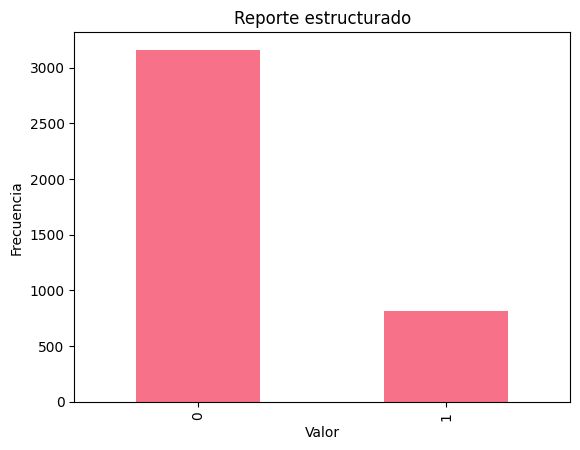

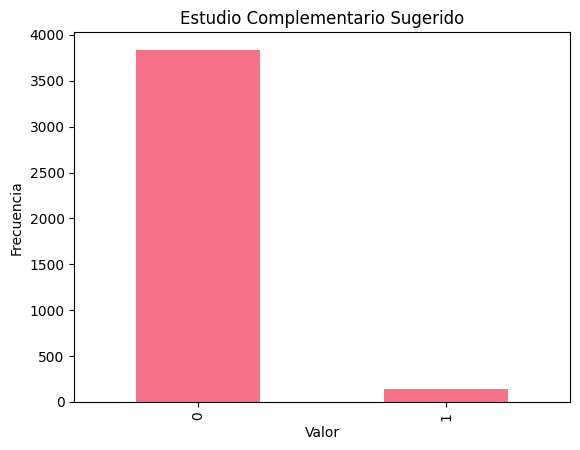

In [26]:
binary_cols = ['Reporte estructurado', 'Estudio Complementario Sugerido']

for col in binary_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print("Proporción de 1:", df[col].mean())

for col in binary_cols:
    df[col].value_counts().plot(kind='bar', title=col)
    plt.xlabel('Valor')
    plt.ylabel('Frecuencia')
    plt.show()

### 4. Análisis de Palabras Clave y Frases Comunes
Para entender mejor cómo los especialistas describen los diagnósticos en la sección de `Hallazgos`, contamos cuáles son las palabras y frases cortas (n-gramas) que más se repiten. Esto nos ayuda a descubrir los términos clave y los patrones más comunes que usan los médicos para referirse a las enfermedades principales, facilitando su posterior clasificación.

In [27]:
# Muestra aleatoria de hallazgos y opiniones
print(df['Hallazgos'].sample(20, random_state=1))
print(df['Opinión'].sample(20, random_state=1))

all_text = ' '.join(df['Hallazgos'].dropna().astype(str).tolist()).lower()
words = re.findall(r'\b\w+\b', all_text)
counter = Counter(words)
print(counter.most_common(50))  # 50 palabras más frecuentes

vectorizer = CountVectorizer(ngram_range=(2,3), max_features=50)
X = vectorizer.fit_transform(df['Hallazgos'].dropna().astype(str).str.lower())
ngrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1
ngram_freq = sorted(zip(ngrams, counts), key=lambda x: -x[1])
print(ngram_freq)

3047    surcos y circunvoluciones simétricos. sistema ...
1064    prominencia de los surcos en las convejidades ...
1889    prominencia surcos, circunvoluciones y espacio...
1759    parénquima cerebral de densidad homogénea, sin...
1674    hemorragia intraparenquimatosa: no. signos de ...
419     parénquima cerebral de densidad homogénea, sin...
950     surcos y circunvoluciones simétricos. sistema ...
788     surcos y circunvoluciones simétricos prominent...
861     surcos y circunvoluciones simétricos. sistema ...
1539    colecciones extra-axiales subdurales crónicas ...
2565    la hipodensidad la sustancia blanca periventri...
494     surcos y circunvoluciones simétricos y promine...
3269    hemorragia intraparenquimatosa: no. signos de ...
2442    surcos y espacio subaracnoideo prominente por ...
3029    surcos y espacios subaracnoideos prominentes p...
3593    signos de sangrado. hematoma subdural: si, fro...
689     prominencia de los surcos en las convejidades ...
1406    surcos

### 4b. Análisis de Palabras Clave con Texto Limpio

Ahora el análisis de frecuencias y n-gramas se ejecuta **sobre el texto ya depurado** (`Hallazgos_limpio`), lo que garantiza que solo aparezcan términos con valor diagnóstico real en las visualizaciones y en el vectorizador TF-IDF.


── TOP 20 TÉRMINOS: Hallazgos (texto limpio) ──────────────
  normal                              5552
  media                               4101
  linea                               3817
  ventricular                         3751
  sistema                             3668
  normales                            3495
  senos                               3441
  hemorragia                          3393
  signos                              3258
  central                             3109
  cerebral                            3100
  mastoides                           3081
  orbitas                             2955
  adecuada                            2945
  paranasales                         2877
  colecciones                         2638
  sangrado                            2470
  surcos                              2436
  ventriculo                          2435
  izquierdo                           2396

── TOP 20 N-GRAMAS: Hallazgos (texto limpio) ─────────────
  linea media      

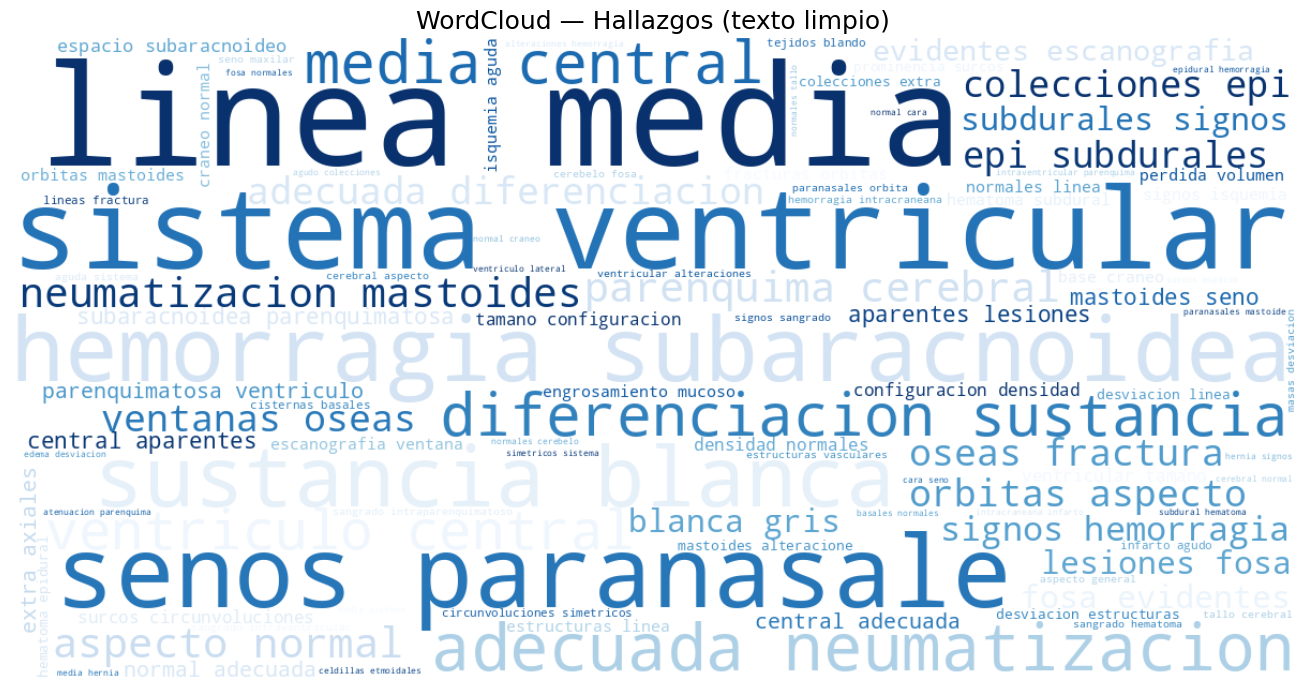


── TOP 20 TÉRMINOS: Opiniones (texto limpio) ──────────────
  cerebral                            1587
  estudio                             1148
  signos                              1030
  cambios                             872
  lesiones                            859
  lesion                              802
  izquierda                           648
  derecha                             625
  hematoma                            602
  volumen                             600
  normales                            600
  perdida                             596
  espacio                             594
  frontal                             592
  derecho                             572
  intracraneal                        546
  hemorragia                          519
  izquierdo                           503
  ocupantes                           444
  aguda                               417

── TOP 20 N-GRAMAS: Opiniones (texto limpio) ─────────────
  perdida volumen                   

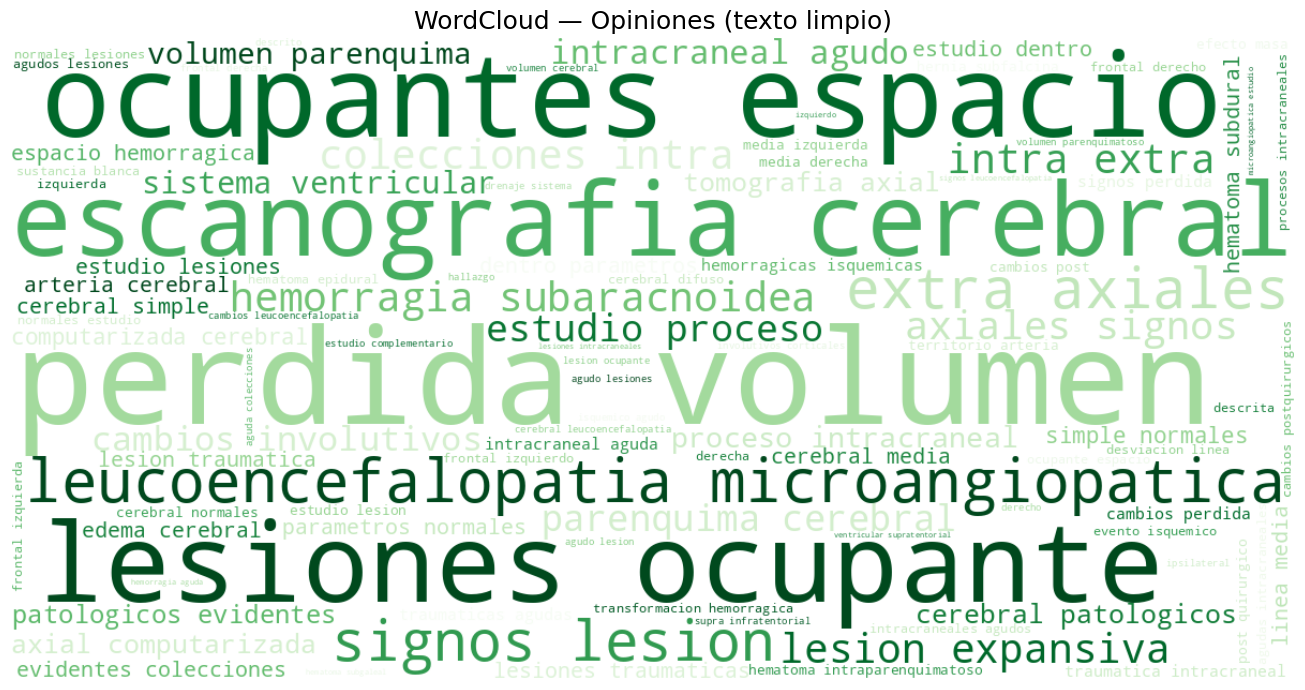

In [28]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter
from wordcloud import WordCloud

# ─── WordCloud y frecuencias sobre texto limpio ────────────────
for col_orig, col_limpio, cmap, titulo in [
    ('Hallazgos', 'Hallazgos_limpio', 'Blues',  'Hallazgos (texto limpio)'),
    ('Opinión',   'Opinión_limpio',   'Greens', 'Opiniones (texto limpio)'),
]:
    corpus = ' '.join(df[col_limpio].dropna().astype(str).tolist())
    words  = corpus.split()
    counter = Counter(words)

    print(f'\n── TOP 20 TÉRMINOS: {titulo} ──────────────')
    for term, freq in counter.most_common(20):
        print(f'  {term:<35} {freq}')

    # N-gramas (2-3) sobre texto limpio — sin stopwords adicionales porque ya se limpiaron
    vec = CountVectorizer(ngram_range=(2, 3), max_features=20)
    X   = vec.fit_transform(df[col_limpio].dropna().astype(str))
    ngrams_freq = sorted(
        zip(vec.get_feature_names_out(), X.sum(axis=0).A1),
        key=lambda x: -x[1]
    )
    print(f'\n── TOP 20 N-GRAMAS: {titulo} ─────────────')
    for ng, freq in ngrams_freq:
        print(f'  {ng:<45} {freq}')

    # WordCloud
    wc = WordCloud(
        width=1200, height=600, background_color='white',
        colormap=cmap, max_words=100
    ).generate(corpus)
    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud — {titulo}', fontsize=18)
    plt.tight_layout()
    plt.show()


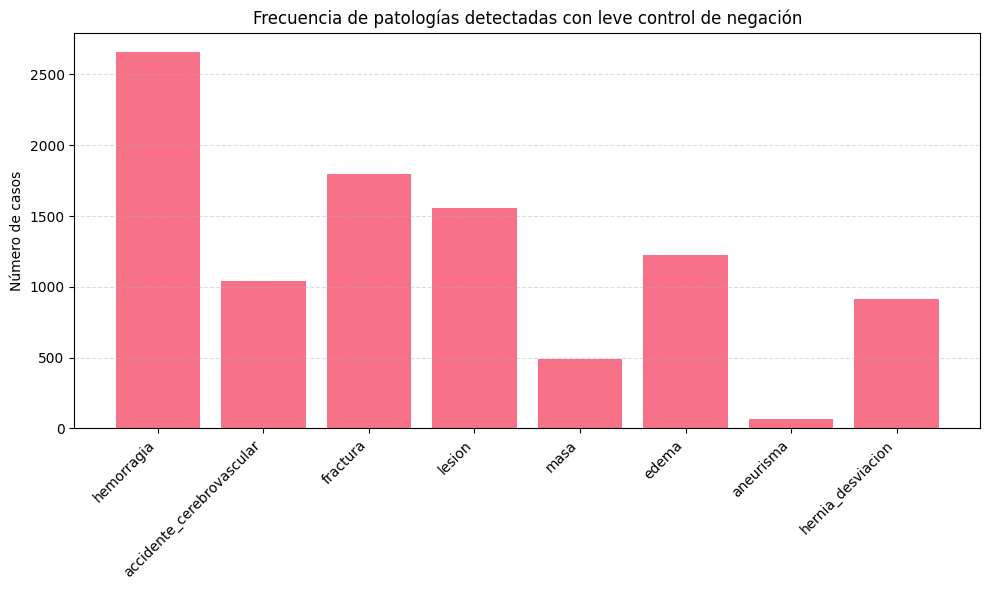

{'hemorragia': 2661, 'accidente_cerebrovascular': 1038, 'fractura': 1800, 'lesion': 1559, 'masa': 487, 'edema': 1228, 'aneurisma': 66, 'hernia_desviacion': 912}


In [29]:
# 1. Diccionario clínico: patologías / sinónimos
PATOLOGIAS = {
    "hemorragia": [
        r"hemorragia", r"hematoma", r"sangrado",
        r"coleccion hematic", r"hematocele"
    ],
    "accidente_cerebrovascular": [
        r"infarto", r"isquemia", r"ictus", r"acv",
        r"evento cerebrovascular", r"hipodensidad sugestiva de isquemia"
    ],
    "fractura": [
        r"fractura", r"linea de fractura", r"trazo de fractura"
    ],
    "lesion": [
        r"lesion", r"lesiones", r"area lesion", r"contusion"
    ],
    "masa": [
        r"masa", r"lesion ocupante de espacio", r"loe", r"tumor",
        r"neoplasia", r"lesion nodular"
    ],
    "edema": [
        r"edema", r"hipodensidad difusa compatible con edema"
    ],
    "aneurisma": [
        r"aneurisma", r"dilatacion aneurismatica"
    ],
    "hernia_desviacion": [
        r"hernia", r"herniacion",
        r"desviaci[oó]n de la l[ií]nea media", r"desviacion de la linea media"
    ]
}
# 2. Negaciones robustas
NEGACIONES = [
    r"no se observa", r"no se evidencia", r"no hay",
    r"sin evidencia de", r"sin signos de", r"ausencia de",
    r"negativa para", r"niega", r"descarta"
]

# 3. Función para detección
def detectar_patologia(texto, patrones_pos, patrones_neg, ventana=60):
    if not isinstance(texto, str):
        return False

    texto = texto.lower()

    # Buscar patrones positivos
    for pos in patrones_pos:
        for match in re.finditer(pos, texto):
            start = match.start()

            # Revisar si hay negaciones antes dentro de una ventana contextual
            ventana_inicio = max(0, start - ventana)
            contexto = texto[ventana_inicio:start]

            if not any(re.search(neg, contexto) for neg in patrones_neg):
                return True

    return False

# 4. Aplicación y conteo
resultados = {}

for nombre, patrones in PATOLOGIAS.items():
    count = df["Hallazgos"].apply(
        lambda x: detectar_patologia(x, patrones, NEGACIONES)
    ).sum()

    resultados[nombre] = count

# 5. Visualización 
plt.figure(figsize=(10, 6))
plt.bar(resultados.keys(), resultados.values())
plt.ylabel("Número de casos")
plt.title("Frecuencia de patologías detectadas con leve control de negación")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
print(resultados)

## Selección de categorías diagnósticas predominantes

Tras el análisis exploratorio de frecuencias y relevancia clínica, **consideramos como opción predominante** las siguientes categorías para el modelo de clasificación automática:

- hemorragia /  hematoma cerebral
- accidente cerebrovascular
- fractura
- masa

Esto por su frecuencia, relevancia clínica y claridad en los reportes. Se crearán variables binarias para cada una, que servirán como etiquetas principales en el entrenamiento y validación del modelo.

### 5. Algoritmo de Etiquetado de Diagnósticos Basado en Reglas
Apoyándose en el estudio léxico anterior, se construye una heurística computacional sensible al contexto. Esta función toma secuencias de palabras clave (ej., 'hemorragia', 'isquemia') y reglas de contención lógica —tales como la negación o términos de temporalidad ('secuela', 'antiguo')— para clasificar cada reporte en ejes de posibles diagnósticos (Hemorragia, ACV, Fractura y Efecto de Masa).

In [31]:
def detectar_patologia_robusta(texto, keywords_positivos, keywords_negativos=None):
    """
    Detecta patologías con análisis de contexto robusto.
    
    Args:
        texto: Texto completo del hallazgo
        keywords_positivos: Lista de palabras clave ordenada por especificidad
        keywords_negativos: Lista de términos de antigüedad/cronicidad
    
    Returns:
        1 si detecta patología aguda y presente, 0 en caso contrario
    """
    if not isinstance(texto, str):
        return 0
    
    texto = texto.lower()
    
    keywords_negativos = keywords_negativos or [
        'antiguo', 'antigua', 'antiguos', 'antiguas',
        'cronico', 'cronica', 'cronicos', 'cronicas',
        'crónico', 'crónica', 'crónicos', 'crónicas',
        'viejo', 'vieja', 'viejos', 'viejas',
        'residual', 'residuales',
        'secuela', 'secuelar', 'secuelas',
        'previo', 'previa', 'previos', 'previas',
        'conocido', 'conocida', 'conocidos', 'conocidas',
        'ya descrito', 'ya descritos', 'ya descrita', 'ya descritas',
        'ya visualizado', 'ya visualizada', 'ya visualizados', 'ya visualizadas',
        'sin cambios', 'estable', 'estables',
        'resolucion', 'resolución'
    ]
    
    negaciones_contextuales = [
        'sin', 'descarta', 'descartado', 'descartada', 'descartados', 'descartadas',
        'negativo', 'negativa', 'negativos', 'negativas',
        'ausencia', 'ausencia de', 'ausente', 'ausentes',
        'sin evidencia', 'sin evidencia de',
        'sin signos', 'sin signos de',
        'sin signos indirectos', 'sin signos indirectos de',
        'no se observa', 'no se observan',
        'no se evidencia', 'no se evidencian',
        'no se identifica', 'no se identifican',
        'libre de', 'negativo para', 'negativa para'
    ]
    
    keywords_ordenadas = sorted(keywords_positivos, key=len, reverse=True)
    oraciones = re.split(r'[.;]', texto)
    
    for oracion in oraciones:
        oracion = oracion.strip()
        
        keyword_encontrada = None
        for kw in keywords_ordenadas:
            if kw in oracion:
                keyword_encontrada = kw
                break
        
        if not keyword_encontrada:
            continue
        
        patron_keyword_no = re.escape(keyword_encontrada) + r'\s*:\s*no\b'
        if re.search(patron_keyword_no, oracion):
            continue
        
        patron_estructurado = re.escape(keyword_encontrada) + r'\s*:[^.;]*?\b(no|negativo|negativa|ausente)\b'
        if re.search(patron_estructurado, oracion):
            continue
        
        idx_kw = oracion.find(keyword_encontrada)
        segmento_previo = oracion[max(0, idx_kw-50):idx_kw]
        
        if any(neg in segmento_previo for neg in negaciones_contextuales):
            continue
        
        patron_sin_hallazgos = r'sin\s+(hallazgos?|evidencia|signos?)\s+(indirectos?\s+)?(de\s+)?' + re.escape(keyword_encontrada)
        if re.search(patron_sin_hallazgos, oracion):
            continue
        
        if any(ant in oracion for ant in keywords_negativos):
            continue
        
        if 'ya conocido' in oracion or 'ya conocida' in oracion:
            continue
        if 'sin cambios' in oracion and keyword_encontrada in oracion:
            continue
        if 'resolucion' in oracion or 'resolución' in oracion:
            continue
        
        return 1
    
    return 0


# Usa df ya en memoria (normalizado en celdas anteriores)
# Mantener solo columnas originales + las 4 nuevas
columnas_originales = ['Fecha(dd/mm/yyyy)', 'Modalidad', 'Estudio', 'Técnica', 
                       'Datos Clínicos', 'Hallazgos', 'Opinión', 
                       'Reporte estructurado', 'Estudio Complementario Sugerido', 
                       'Hallazgo Crítico', 'Estudio Normal']

# Definir keywords
keywords_hemorragia = [
    'hemorragia subaracnoidea', 'hemorragia subaracnoideas',
    'hematoma subdural', 'hematoma epidural',
    'sangrado intraparenquimatoso', 'sangrado intraventricular',
    'hemorragia intraparenquimatosa', 'hemorragia intraventricular',
    'hemorragia interhemisferica', 'hemorragia parenquimatosa',
    'foco hemorragico', 'focos hemorragicos',
    'foco de hemorragia', 'focos de hemorragia',
    'hemorragia', 'hemorragico', 'hemorragica', 'hemorragicos', 'hemorragicas',
    'hematoma', 'hematomas',
    'sangrado', 'sangrados'
]

keywords_acv_isquemico = [
    'infarto cerebral', 'infarto lacunar', 'infartos lacunares',
    'evento isquemico', 'evento cerebrovascular',
    'area de isquemia', 'areas de isquemia',
    'zona de isquemia', 'zonas de isquemia',
    'evento vascular cerebral',
    'territorio vascular',
    'hipodensidad cortical', 'hipodensidad subcortical',
    'infarto', 'infartos',
    'isquemia', 'isquemias',
    'isquemico', 'isquemica', 'isquemicos', 'isquemicas',
    'ictus',
    'acv'
]

keywords_fractura = [
    'fractura craneal', 'fractura de craneo',
    'fractura lineal', 'fractura deprimida',
    'fractura conminuta', 'fractura hundimiento',
    'fractura', 'fracturas'
]

keywords_masa = [
    'lesion ocupante', 'lesiones ocupantes',
    'efecto de masa',
    'lesion tumoral', 'proceso expansivo',
    'proceso ocupante',
    'masa', 'masas',
    'tumor', 'tumores', 'tumoral', 'tumorales',
    'neoplasia', 'neoplasias', 'neoplasica', 'neoplasico'
]

# Aplicar detección solo a las 4 categorías
df['hemorragia'] = df['Hallazgos'].apply(
    lambda x: detectar_patologia_robusta(x, keywords_hemorragia)
)

df['acv'] = df['Hallazgos'].apply(
    lambda x: detectar_patologia_robusta(x, keywords_acv_isquemico)
)

df['fractura'] = df['Hallazgos'].apply(
    lambda x: detectar_patologia_robusta(x, keywords_fractura)
)

df['masa'] = df['Hallazgos'].apply(
    lambda x: detectar_patologia_robusta(x, keywords_masa)
)

# Mantener solo columnas necesarias
columnas_finales = columnas_originales + ['hemorragia', 'acv', 'fractura', 'masa']
df_final = df[columnas_originales] # para guardar todos los datos sin ningun etiquetado

df_final.to_excel('../data/data_cleaned.xlsx', index=False)
print(f"Hemorragia: {df['hemorragia'].sum()} casos")
print(f"ACV isquémico: {df['acv'].sum()} casos")
print(f"Fractura: {df['fractura'].sum()} casos")
print(f"Masa: {df['masa'].sum()} casos")

for col in ['hemorragia', 'acv', 'fractura', 'masa']:
    print(f"\nEjemplos donde {col}=1:")
    display(df[df[col]==1][['Hallazgos', col, 'Hallazgo Crítico']].sample(5, random_state=1))


Hemorragia: 3319 casos
ACV isquémico: 1751 casos
Fractura: 1721 casos
Masa: 590 casos

Ejemplos donde hemorragia=1:


,Hallazgos,hemorragia,Hallazgo Crítico
2739,surcos y circunvoluciones simétricos. sistema ...,1,0
1083,la atenuación del parénquima es normal para la...,1,0
948,hemorragia intraparenquimatosa: no. signos de ...,1,1
1391,surcos y circunvoluciones simétricos. sistema ...,1,0
1156,prominencia de los surcos y de las circunvoluc...,1,0



Ejemplos donde acv=1:


,Hallazgos,acv,Hallazgo Crítico
3866,extensa hemorragia subaracnoidea supra e infra...,1,1
3552,signos de sangrado. hematoma subdural: no. hem...,1,1
69,signos de sangrado. hematoma subdural: no. hem...,1,1
682,signos de sangrado. hematoma subdural: no. hem...,1,0
1213,focos hiperdensos en el espacio subaracnoideo ...,1,0



Ejemplos donde fractura=1:


,Hallazgos,fractura,Hallazgo Crítico
473,hemorragia intraparenquimatosa: hemorragia sub...,1,1
1665,surcos y circunvoluciones simétricos. sistema ...,1,0
2209,surcos y circunvoluciones simétricos. sistema ...,1,0
1518,prominencia de surcos y el espacio subaracnoid...,1,0
177,surcos y circunvoluciones simétricos. sistema ...,1,0



Ejemplos donde masa=1:


,Hallazgos,masa,Hallazgo Crítico
3598,se identifica dos lesiones con morfología irre...,1,1
1789,prominencia de los surcos en las convejidades ...,1,0
124,prominencia de surcos y cisuras por pérdida de...,1,0
3442,signos de sangrado. hematoma subdural: no. hem...,1,1
592,"parénquima cerebral de densidad homogénea, sin...",1,0
